# Прогнозирование продаж новых коммерческих автомобилей марки ГАЗ и спроса на них с применением классических ML-моделей и архитектуры Transformer

В данном ноутбуке мы решаем задачу прогнозирования двух целевых переменных (target):

- quantity — объём продаж новых коммерческих автомобилей ГАЗ;
- applications — объём спроса, выраженный количеством заявок.

Сравниваются сезонный наивный прогноз, **SARIMA, Random Forest, XGBoost и Transformer**.

Методология адаптирована к небольшому по-месячному ряду: последние 12 месяцев — test, предыдущие 12 — validation, более ранние данные — train. Данные не миксуются.

> Для ML и Transformer тест прогнозируется рекурсивно. Фактические значения целевой переменной из будущих тестовых месяцев не используются при создании лагов следующего месяца.

## Библиотеки и настройки

Устанавливаются недостающие пакеты. Все случайные генераторы фиксируются для воспроизводимости.

In [ ]:
import importlib.util
import random
import subprocess
import sys
import time
import warnings
from pathlib import Path

PACKAGES = {
    "joblib": "joblib",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "plotly": "plotly",
    "sklearn": "scikit-learn",
    "statsmodels": "statsmodels",
    "torch": "torch",
    "xgboost": "xgboost",
}
missing = [pkg for module, pkg in PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import torch
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from torch import nn
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

TARGETS = ["quantity", "applications"]
LOOKBACK = 12
OUTPUT_DIR = Path("gaz_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Загрузка и объединение данных

Файл gibdd.csv содержит детальные регистрации автомобилей в разрезе моделей и регионов, поэтому параметр quantity суммируется до уровня **один месяц — одна строка**.  
Файл dataset_month.csv уже содержит месячные внешние факторы и applications.

In [ ]:
def find_files():
    csv_files = []
    for folder in [Path.cwd(), Path("/content"), Path("/mnt/data")]:
        if folder.exists():
            csv_files.extend(folder.glob("*.csv"))

    monthly_path = gibdd_path = None
    for path in dict.fromkeys(csv_files):
        try:
            cols = set(pd.read_csv(path, sep=None, engine="python", nrows=2).columns.str.strip())
        except Exception:
            continue
        if {"year", "month", "applications"}.issubset(cols):
            monthly_path = path
        if {"year", "month", "model", "region", "quantity"}.issubset(cols):
            gibdd_path = path

    if monthly_path and gibdd_path:
        return monthly_path, gibdd_path

    try:
        from google.colab import files
        print("Загрузите dataset_month*.csv и gibdd*.csv")
        files.upload()
        return find_files()
    except ImportError as exc:
        raise FileNotFoundError("Не найдены dataset_month*.csv и gibdd*.csv") from exc


def numeric_frame(frame):
    result = frame.copy()
    result.columns = result.columns.str.strip()
    for column in result.columns:
        if column not in {"year", "month"}:
            result[column] = pd.to_numeric(
                result[column].astype(str).str.replace(",", ".", regex=False).str.strip(),
                errors="coerce",
            )
    return result


monthly_path, gibdd_path = find_files()
monthly = numeric_frame(pd.read_csv(monthly_path, sep=None, engine="python"))
gibdd = pd.read_csv(gibdd_path, sep=None, engine="python")
gibdd.columns = gibdd.columns.str.strip()
gibdd["quantity"] = pd.to_numeric(gibdd["quantity"], errors="coerce")

sales = (
    gibdd.groupby(["year", "month"], as_index=False)["quantity"]
    .sum()
    .rename(columns={"quantity": "quantity"})
)

data = monthly.merge(sales, on=["year", "month"], how="inner")
data["date"] = pd.to_datetime(dict(year=data["year"], month=data["month"], day=1))
data = data.sort_values("date").reset_index(drop=True)

print("Период:", data["date"].min().date(), "—", data["date"].max().date())
print("Размер объединённого датасета:", data.shape)
display(data[["date", "quantity", "applications"]].head())

Период: 2019-01-01 — 2025-12-01
Размер объединённого датасета: (84, 51)


,date,quantity,applications
0,2019-01-01,3741,19845
1,2019-02-01,4179,14742
2,2019-03-01,4717,49840
3,2019-04-01,5205,40376
4,2019-05-01,4103,28035


## 2. Очистка, пропуски, выбросы и признаки без утечки

В модели включаются преимущественно **макроэкономические, ценовые и конкурентные факторы**, которые могут быть известны как факт или сценарий. Текущие значения некоторых признаков share_* (доля рынка), turnover_* (оборачиваемость) и канальных показателей заявок не используются в качестве предикторов, так как они рассчитываются с использованием фактических продаж/заявок прогнозируемого месяца. Это позволяет избежать утечки целевой переменной и получить реалистичную оценку качества прогноза.

Пропуски заполняются предыдущим известным значением, а остаточные — медианой **train**. Выбросы во внешних признаках ограничиваются правилом 3 × IQR, границы также рассчитываются только на train. Сами показатели quantity и applications не обрезаются: кризисы и всплески — часть задачи прогнозирования.

In [ ]:
EXOG_CANDIDATES = [
    "bus_uaz", "bort_uaz", "cmf_uaz",
    "wa_sprice_lcv", "wa_sprice_ldt", "wa_sprice_total",
    "gdp", "cp_index", "rt_turnover", "volume_services", "construction",
    "industrial_production", "agriculture", "road_freight_turnover",
    "passenger_turnover", "business_index", "exchange_rate", "urals", "key_rate",
]
EXOG = [column for column in EXOG_CANDIDATES if column in data.columns]

test_start = data["date"].iloc[-12]
valid_start = data["date"].iloc[-24]
train_mask = data["date"] < valid_start

for column in EXOG:
    data[column] = data[column].ffill()
    data[column] = data[column].fillna(data.loc[train_mask, column].median())

outlier_rows = []
for column in EXOG:
    train_values = data.loc[train_mask, column].dropna()
    q1, q3 = train_values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
    count = int(((data[column] < lower) | (data[column] > upper)).sum())
    outlier_rows.append([column, count, lower, upper])
    data[column] = data[column].clip(lower, upper)

assert data[TARGETS].notna().all().all(), "В целевых переменных есть пропуски."

quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique": data.nunique(),
})
outliers = pd.DataFrame(outlier_rows, columns=["feature", "outliers", "lower", "upper"])

print(f"Train: до {valid_start:%Y-%m}")
print(f"Validation: {valid_start:%Y-%m} — {(test_start - pd.offsets.MonthBegin(1)):%Y-%m}")
print(f"Test: {test_start:%Y-%m} — {data['date'].max():%Y-%m}")
display(quality.loc[["quantity", "applications"] + EXOG])
display(outliers.sort_values("outliers", ascending=False).head(10))

Train: до 2024-01
Validation: 2024-01 — 2024-12
Test: 2025-01 — 2025-12


,dtype,missing,unique
quantity,int64,0,84
applications,int64,0,84
bus_uaz,int64,0,75
bort_uaz,int64,0,72
cmf_uaz,float64,0,73
wa_sprice_lcv,int64,0,80
wa_sprice_ldt,int64,0,82
wa_sprice_total,int64,0,82
gdp,float64,0,40
cp_index,float64,0,22


,feature,outliers,lower,upper
18,key_rate,29,-1.43750,14.75000
14,passenger_turnover,7,-0.31075,0.32800
9,volume_services,6,-0.21250,0.28800
12,agriculture,2,-0.13900,0.20575
8,rt_turnover,1,-0.28800,0.31925
0,bus_uaz,1,-65.25000,577.00000
2,cmf_uaz,1,-37.00000,890.50000
7,cp_index,1,-0.01300,0.02375
1,bort_uaz,0,-163.75000,1311.50000
6,gdp,0,-0.24600,0.26675


## 3. Разведочный анализ: тренд, сезонность, макрофакторы и структурные сдвиги

EDA включает динамику целей, STL-разложение с годовой сезонностью, корреляции с внешними факторами и простой поиск смены уровня ряда.  
Структурный сдвиг оценивается как разница средних за 6 месяцев до и после точки, нормированная на стандартное отклонение ряда.

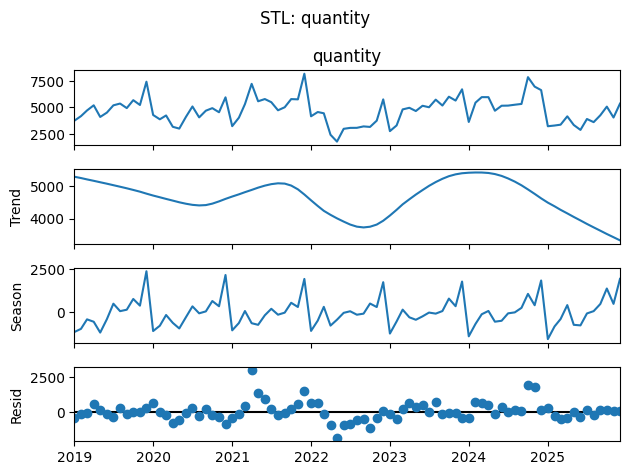

Кандидаты структурных сдвигов: quantity


,date,score
66,2025-01-01,2.265947
33,2022-04-01,2.190073
6,2020-01-01,1.491074


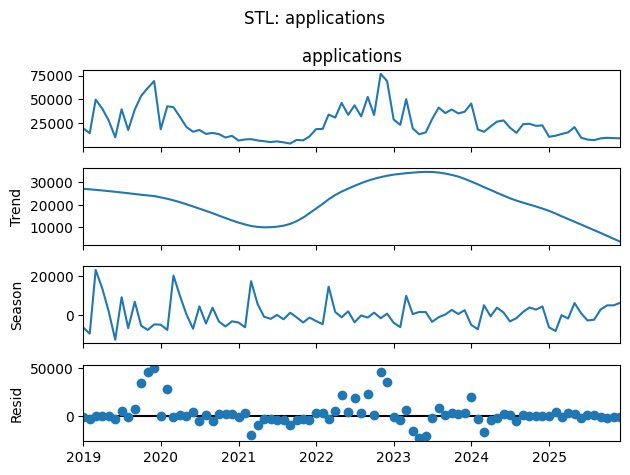

Кандидаты структурных сдвигов: applications


,date,score
9,2020-04-01,1.734881
42,2023-01-01,1.579132
31,2022-02-01,1.553057


In [ ]:
def structural_shifts(series, dates, window=6, top_n=3):
    rows = []
    std = series.std() or 1
    for i in range(window, len(series) - window):
        left = series.iloc[i - window:i].mean()
        right = series.iloc[i:i + window].mean()
        rows.append((dates.iloc[i], abs(right - left) / std))
    shifts = pd.DataFrame(rows, columns=["date", "score"]).sort_values("score", ascending=False)

    selected = []
    for _, row in shifts.iterrows():
        if all(abs((row["date"] - old["date"]).days) > 150 for old in selected):
            selected.append(row)
        if len(selected) == top_n:
            break
    return pd.DataFrame(selected)


for target in TARGETS:
    fig = px.line(data, x="date", y=target, markers=True, title=f"Динамика {target}")
    fig.show()

    stl = STL(data.set_index("date")[target], period=12, robust=True).fit()
    stl.plot()
    plt.suptitle(f"STL: {target}")
    plt.tight_layout()
    plt.show()

    print(f"Кандидаты структурных сдвигов: {target}")
    display(structural_shifts(data[target], data["date"]))

corr_cols = TARGETS + EXOG
corr = data[corr_cols].corr()

fig = go.Figure(
    go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.index,
        zmin=-1,
        zmax=1,
    )
)
fig.update_layout(title="Корреляции target и внешних факторов", height=700)
fig.show()

macro_preview = [c for c in ["gdp", "industrial_production", "exchange_rate", "key_rate"] if c in EXOG]
z = data[["date", "quantity"] + macro_preview].copy()
for column in ["quantity"] + macro_preview:
    z[column] = (z[column] - z[column].mean()) / z[column].std(ddof=0)

fig = go.Figure()
for column in ["quantity"] + macro_preview:
    fig.add_trace(go.Scatter(x=z["date"], y=z[column], mode="lines", name=column))
fig.update_layout(
    title="Продажи и макрофакторы на единой стандартизированной шкале",
    xaxis_title="Дата",
    yaxis_title="Z-score",
)
fig.show()

**ВЫВОДЫ:**

**Разведочный анализ** показал, что продажи новых коммерческих автомобилей ГАЗ (quantity) характеризуются выраженной годовой сезонностью и существенными изменениями общего уровня продаж. Наиболее высокие значения обычно наблюдаются в конце года, особенно в декабре, тогда как начало года характеризуется более низким уровнем продаж. В рассматриваемом периоде также выявляются выраженные структурные изменения, в частности в 2020, 2022 и 2025 годах.


Продажи демонстрируют заметную положительную связь с показателями общей экономической активности, прежде всего GDP, промышленным производством и оборотом розничной торговли. При этом простой линейной зависимости от ключевой ставки практически не наблюдается, что не исключает наличия запаздывающих или нелинейных эффектов.


Количество заявок (applications) является значительно более волатильным рядом по сравнению с фактическими продажами. Для него наблюдаются крупные изменения тренда и структурные сдвиги, а связь с базовыми макроэкономическими показателями выражена слабее. Это указывает на возможное дополнительное влияние маркетинговой активности и особенностей формирования заявок.


Полученные результаты обосновывают использование моделей, учитывающих лаговые значения, годовую сезонность, внешние факторы и нелинейные зависимости. Поэтому дальнейшее сравнение SARIMA, Random Forest, XGBoost и Transformer является методологически оправданным.

## 4. Lag-features (продажи прошлых преиодов) и rolling statistics (средние продажи за период)

Для Random Forest и XGBoost создаются лаги 1, 2, 3, 6 и 12 месяцев, скользящие средние и стандартные отклонения за 3, 6 и 12 месяцев, линейный тренд и циклические признаки месяца.

Rolling statistics предварительно сдвигаются на один месяц, поэтому текущее значение target не попадает в признаки своей строки.

In [ ]:
LAGS = [1, 2, 3, 6, 12]
WINDOWS = [3, 6, 12]


def add_features(frame, target):
    result = frame.copy()
    result["time_idx"] = np.arange(len(result))
    result["month_sin"] = np.sin(2 * np.pi * result["month"] / 12)
    result["month_cos"] = np.cos(2 * np.pi * result["month"] / 12)

    for lag in LAGS:
        result[f"lag_{lag}"] = result[target].shift(lag)
    for window in WINDOWS:
        shifted = result[target].shift(1)
        result[f"roll_mean_{window}"] = shifted.rolling(window).mean()
        result[f"roll_std_{window}"] = shifted.rolling(window).std()

    features = (
        EXOG
        + ["time_idx", "month_sin", "month_cos"]
        + [f"lag_{lag}" for lag in LAGS]
        + [f"roll_mean_{w}" for w in WINDOWS]
        + [f"roll_std_{w}" for w in WINDOWS]
    )
    return result, features


example, example_features = add_features(data, "quantity")
print("Число признаков:", len(example_features))
display(example[["date", "quantity"] + example_features[-8:]].tail())

Число признаков: 33


,date,quantity,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_mean_12,roll_std_3,roll_std_6,roll_std_12
79,2025-08-01,3612,3291.0,5260.0,3375.333333,3491.500000,4687.666667,517.355133,464.488428,1698.258538
80,2025-09-01,4263,3371.0,5335.0,3465.666667,3545.000000,4550.333333,531.819832,455.168980,1714.326549
81,2025-10-01,5079,4161.0,7870.0,3928.000000,3693.666667,4461.000000,325.915633,526.978431,1697.569492
82,2025-11-01,4049,3341.0,6973.0,4318.000000,3846.666667,4228.416667,735.044897,767.961631,1342.002131
83,2025-12-01,5365,2876.0,6642.0,4463.666667,3964.666667,3984.750000,543.530435,728.082596,1026.806092


## 5. Метрики и наивный baseline

Используются MAE, RMSE, MAPE и SMAPE.
Наивный baseline представляет собой **простой сезонный прогноз**, при котором значение целевой переменной на прогнозируемый месяц принимается равным значению того же месяца предыдущего года. Он используется как базовый уровень качества, относительно которого оценивается целесообразность применения более сложных прогнозных моделей.

In [ ]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    eps = 1e-8
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100,
        "SMAPE": np.mean(
            2 * np.abs(y_true - y_pred)
            / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
        ) * 100,
    }


def naive_forecast(frame, target, dates):
    lookup = frame.set_index("date")[target]
    return np.array([lookup.loc[date - pd.DateOffset(years=1)] for date in dates])

## 6. SARIMA

**SARIMA** — статистическая модель прогнозирования временных рядов, учитывающая авторегрессионную зависимость, тренд, ошибки прошлых прогнозов и сезонные колебания. В данной работе сезонный период принимается равным 12 месяцам, что соответствует годовой сезонности месячных данных.

Сначала мы подбираем лучшие настройки SARIMA на отдельном проверочном периоде. Затем, когда лучшие настройки найдены, обучаем модель заново на всей доступной истории до тестового периода и проверяем, насколько хорошо она прогнозирует последние 12 месяцев.

In [ ]:
SARIMA_ORDERS = [(0, 1, 1), (1, 1, 0), (1, 1, 1), (1, 0, 1)]
SARIMA_SEASONAL = [(0, 1, 1, 12), (1, 1, 0, 12), (1, 1, 1, 12)]
SARIMA_GRID = [(order, seasonal) for order in SARIMA_ORDERS for seasonal in SARIMA_SEASONAL]


def fit_sarima(series, order, seasonal_order):
    return SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)


def sarima_forecast(frame, target):
    train = frame.loc[frame["date"] < valid_start, target]
    valid = frame.loc[(frame["date"] >= valid_start) & (frame["date"] < test_start), target]

    search = []
    for order, seasonal in SARIMA_GRID:
        try:
            model = fit_sarima(train, order, seasonal)
            pred = model.forecast(len(valid))
            search.append((metrics(valid, pred)["RMSE"], order, seasonal))
        except Exception:
            continue

    best_rmse, best_order, best_seasonal = min(search, key=lambda row: row[0])
    full_train = frame.loc[frame["date"] < test_start, target]
    final_model = fit_sarima(full_train, best_order, best_seasonal)
    test_pred = final_model.forecast(12).to_numpy()

    print(
        target,
        "best SARIMA:",
        best_order,
        best_seasonal,
        f"validation RMSE={best_rmse:.1f}",
    )
    return test_pred, final_model

## 7. Random Forest и XGBoost

Для обеих моделей используется единая последовательность подготовки данных. Сначала пропущенные значения в признаках заменяются медианными значениями, рассчитанными по обучающей выборке. Такой подход позволяет сохранить наблюдения и при этом снизить влияние отдельных экстремальных значений. Затем числовые признаки приводятся к единому масштабу с помощью стандартизации. Для моделей на основе деревьев решений эта операция не является обязательной, однако её использование делает обработку данных единообразной для всех этапов моделирования и упрощает дальнейшее сравнение моделей.


После подготовки данных выполняется подбор параметров моделей. Для этого используются обучающая и проверочная выборки: модель обучается на обучающей части данных, а различные варианты её параметров сравниваются по качеству прогноза на проверочной выборке. В качестве лучшей выбирается комбинация параметров, обеспечивающая наименьшую ошибку прогноза.


Прогноз на последние 12 месяцев строится рекурсивным способом. Это означает, что сначала модель прогнозирует значение на первый месяц, после чего полученный прогноз используется при формировании лаговых признаков для следующего месяца. Затем прогнозируется второй месяц, его значение также добавляется в доступную историю, и процедура повторяется до получения прогноза на весь горизонт из 12 месяцев.


Такой подход имитирует реальную ситуацию прогнозирования: на момент построения прогноза фактические значения будущих месяцев ещё неизвестны. Поэтому при расчёте лаговых и скользящих признаков для последующих месяцев используются ранее полученные прогнозы, а не реальные значения целевой переменной из тестового периода. Это позволяет избежать утечки информации из будущего и получить более объективную оценку качества моделей.

In [ ]:
RF_GRID = [
    {"n_estimators": 300, "max_depth": depth, "min_samples_leaf": leaf}
    for depth, leaf in [(4, 1), (6, 1), (None, 2)]
]
XGB_GRID = [
    {"n_estimators": n, "max_depth": depth, "learning_rate": lr}
    for n, depth, lr in [(250, 2, 0.03), (300, 3, 0.03), (250, 2, 0.05)]
]


def make_ml_model(kind, params):
    if kind == "RandomForest":
        regressor = RandomForestRegressor(
            random_state=SEED,
            n_jobs=-1,
            **params,
        )
    else:
        regressor = XGBRegressor(
            random_state=SEED,
            n_jobs=-1,
            objective="reg:squarederror",
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            **params,
        )
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", regressor),
    ])


def fit_ml(frame, target, kind, params, end_date):
    featured, features = add_features(frame, target)
    train = featured[featured["date"] < end_date].dropna(subset=[target])
    model = make_ml_model(kind, params)
    model.fit(train[features], train[target])
    return model, features


def recursive_ml(model, frame, target, features, dates):
    temp = frame.copy()
    temp.loc[temp["date"].isin(dates), target] = np.nan
    predictions = []

    for date in dates:
        featured, _ = add_features(temp, target)
        row = featured.loc[featured["date"] == date, features]
        pred = max(0.0, float(model.predict(row)[0]))
        predictions.append(pred)
        temp.loc[temp["date"] == date, target] = pred

    return np.array(predictions)


def tune_ml(frame, target, kind, grid):
    valid_dates = frame.loc[
        (frame["date"] >= valid_start) & (frame["date"] < test_start), "date"
    ].tolist()
    valid_actual = frame.loc[frame["date"].isin(valid_dates), target].to_numpy()

    scores = []
    for params in grid:
        model, features = fit_ml(frame, target, kind, params, valid_start)
        pred = recursive_ml(model, frame, target, features, valid_dates)
        scores.append((metrics(valid_actual, pred)["RMSE"], params))

    best_rmse, best_params = min(scores, key=lambda row: row[0])
    final_model, features = fit_ml(frame, target, kind, best_params, test_start)
    test_dates = frame.loc[frame["date"] >= test_start, "date"].tolist()
    test_pred = recursive_ml(final_model, frame, target, features, test_dates)

    print(kind, target, best_params, f"validation RMSE={best_rmse:.1f}")
    return test_pred, final_model, features

## 8. Transformer для временных рядов

Используется компактная модель **TransformerEncoder**, поскольку в исходных данных доступно только 84 месячных наблюдения. Увеличение размера модели при таком объёме данных могло бы привести к переобучению и неоправданному росту вычислительных затрат.


На вход модели подаются данные за 12 предыдущих месяцев: прошлые значения целевой переменной, внешние экономические факторы и календарные признаки. Дополнительно используются внешние и календарные показатели того месяца, для которого строится прогноз, если они известны заранее или заданы в рамках прогнозного сценария.


Проверочная выборка используется для контроля качества модели в процессе обучения и выбора оптимального количества эпох. После определения подходящей длительности обучения модель заново обучается на объединённых обучающей и проверочной выборках.


Прогноз последних 12 месяцев тестовой выборки строится рекурсивно. Сначала прогнозируется первый месяц, затем полученное значение используется при формировании входных данных для следующего месяца. Процедура повторяется до получения прогноза на весь 12-месячный период.


При построении прогноза на действительно будущие периоды значения макроэкономических показателей ещё неизвестны. Поэтому они должны поступать в модель из внешних прогнозов или заранее подготовленных сценариев развития экономической ситуации.

In [ ]:
CALENDAR = ["month_sin", "month_cos", "time_idx"]


def transformer_frame(frame):
    result = frame.copy()
    result["time_idx"] = np.arange(len(result))
    result["month_sin"] = np.sin(2 * np.pi * result["month"] / 12)
    result["month_cos"] = np.cos(2 * np.pi * result["month"] / 12)
    return result


class TinyTransformer(nn.Module):
    def __init__(self, hist_dim, future_dim, d_model=32):
        super().__init__()
        self.input_layer = nn.Linear(hist_dim, d_model)
        self.position = nn.Parameter(torch.zeros(1, LOOKBACK, d_model))
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=64,
            dropout=0.1,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.head = nn.Sequential(
            nn.Linear(d_model + future_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, history, future):
        encoded = self.encoder(self.input_layer(history) + self.position)
        return self.head(torch.cat([encoded[:, -1], future], dim=1)).squeeze(1)


def transformer_arrays(frame, target, fit_end, scaler_x=None, scaler_y=None):
    tf = transformer_frame(frame)
    x_cols = EXOG + CALENDAR

    if scaler_x is None:
        scaler_x = StandardScaler().fit(tf.loc[tf["date"] < fit_end, x_cols])
        scaler_y = StandardScaler().fit(
            tf.loc[tf["date"] < fit_end, [target]]
        )

    x_scaled = scaler_x.transform(tf[x_cols])
    y_scaled = scaler_y.transform(tf[[target]]).ravel()

    history, future, labels, dates = [], [], [], []
    for i in range(LOOKBACK, len(tf)):
        if tf.loc[i, "date"] >= fit_end:
            continue
        hist = np.column_stack([
            y_scaled[i - LOOKBACK:i],
            x_scaled[i - LOOKBACK:i],
        ])
        history.append(hist)
        future.append(x_scaled[i])
        labels.append(y_scaled[i])
        dates.append(tf.loc[i, "date"])

    return (
        np.asarray(history, dtype=np.float32),
        np.asarray(future, dtype=np.float32),
        np.asarray(labels, dtype=np.float32),
        pd.Series(dates),
        scaler_x,
        scaler_y,
    )


def train_transformer(frame, target, max_epochs=150, patience=15):
    tf = transformer_frame(frame)
    x_cols = EXOG + CALENDAR

    scaler_x = StandardScaler().fit(tf.loc[tf["date"] < valid_start, x_cols])
    scaler_y = StandardScaler().fit(tf.loc[tf["date"] < valid_start, [target]])

    x_all = scaler_x.transform(tf[x_cols])
    y_all = scaler_y.transform(tf[[target]]).ravel()

    histories, futures, labels, dates = [], [], [], []
    for i in range(LOOKBACK, len(tf)):
        hist = np.column_stack([y_all[i - LOOKBACK:i], x_all[i - LOOKBACK:i]])
        histories.append(hist)
        futures.append(x_all[i])
        labels.append(y_all[i])
        dates.append(tf.loc[i, "date"])

    histories = torch.tensor(np.asarray(histories), dtype=torch.float32)
    futures = torch.tensor(np.asarray(futures), dtype=torch.float32)
    labels = torch.tensor(np.asarray(labels), dtype=torch.float32)
    dates = pd.Series(dates)

    train_idx = torch.tensor((dates < valid_start).to_numpy())
    valid_idx = torch.tensor(((dates >= valid_start) & (dates < test_start)).to_numpy())

    model = TinyTransformer(histories.shape[2], futures.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_loss, best_epoch, waits = np.inf, 1, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(
            model(histories[train_idx], futures[train_idx]),
            labels[train_idx],
        )
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            valid_loss = loss_fn(
                model(histories[valid_idx], futures[valid_idx]),
                labels[valid_idx],
            ).item()

        if valid_loss < best_loss - 1e-5:
            best_loss = valid_loss
            best_epoch = epoch
            waits = 0
        else:
            waits += 1
        if waits >= patience:
            break

    # Финальное обучение на train + validation выбранное число эпох.
    scaler_x = StandardScaler().fit(tf.loc[tf["date"] < test_start, x_cols])
    scaler_y = StandardScaler().fit(tf.loc[tf["date"] < test_start, [target]])
    x_scaled = scaler_x.transform(tf[x_cols])
    y_scaled = scaler_y.transform(tf[[target]]).ravel()

    histories, futures, labels = [], [], []
    for i in range(LOOKBACK, tf.index[tf["date"] == test_start][0]):
        histories.append(
            np.column_stack([
                y_scaled[i - LOOKBACK:i],
                x_scaled[i - LOOKBACK:i],
            ])
        )
        futures.append(x_scaled[i])
        labels.append(y_scaled[i])

    histories = torch.tensor(np.asarray(histories), dtype=torch.float32)
    futures = torch.tensor(np.asarray(futures), dtype=torch.float32)
    labels = torch.tensor(np.asarray(labels), dtype=torch.float32)

    final_model = TinyTransformer(histories.shape[2], futures.shape[1])
    optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3)

    for _ in range(best_epoch):
        final_model.train()
        optimizer.zero_grad()
        loss = loss_fn(final_model(histories, futures), labels)
        loss.backward()
        optimizer.step()

    print(target, f"Transformer epochs={best_epoch}, validation loss={best_loss:.4f}")
    return final_model, scaler_x, scaler_y


def recursive_transformer(model, frame, target, scaler_x, scaler_y):
    temp = transformer_frame(frame)
    x_cols = EXOG + CALENDAR
    test_dates = temp.loc[temp["date"] >= test_start, "date"].tolist()
    temp.loc[temp["date"].isin(test_dates), target] = np.nan
    predictions = []

    model.eval()
    for date in test_dates:
        i = temp.index[temp["date"] == date][0]
        history = temp.loc[i - LOOKBACK:i - 1]
        hist_x = scaler_x.transform(history[x_cols])
        hist_y = scaler_y.transform(history[[target]]).ravel()
        hist = np.column_stack([hist_y, hist_x])[None, :, :]

        future = scaler_x.transform(temp.loc[[i], x_cols])
        with torch.no_grad():
            pred_scaled = model(
                torch.tensor(hist, dtype=torch.float32),
                torch.tensor(future, dtype=torch.float32),
            ).item()

        pred = max(0.0, float(scaler_y.inverse_transform([[pred_scaled]])[0, 0]))
        predictions.append(pred)
        temp.loc[i, target] = pred

    return np.array(predictions)

## 9. Обучение, test-прогноз и сравнение моделей

Все модели запускаются для целевых переменных quantity и applications. Для каждой фиксируются время обучения и четыре метрики. Это позволяет отдельно оценить качество и вычислительную стоимость Transformer.

In [ ]:
all_metrics = []
forecast_tables = {}
saved_models = {}
importance_rows = []

test_dates = data.loc[data["date"] >= test_start, "date"].tolist()

for target in TARGETS:
    actual = data.loc[data["date"] >= test_start, target].to_numpy()
    preds = {"Naive_12m": naive_forecast(data, target, test_dates)}
    saved_models[target] = {}

    start = time.perf_counter()
    preds["SARIMA"], saved_models[target]["SARIMA"] = sarima_forecast(data, target)
    sarima_time = time.perf_counter() - start

    model_times = {"Naive_12m": 0.0, "SARIMA": sarima_time}

    for kind, grid in [("RandomForest", RF_GRID), ("XGBoost", XGB_GRID)]:
        start = time.perf_counter()
        pred, model, features = tune_ml(data, target, kind, grid)
        model_times[kind] = time.perf_counter() - start
        preds[kind] = pred
        saved_models[target][kind] = model

        values = model.named_steps["model"].feature_importances_
        values = values / values.sum()
        importance_rows.extend(
            [[target, kind, feature, value] for feature, value in zip(features, values)]
        )

    start = time.perf_counter()
    transformer, scaler_x, scaler_y = train_transformer(data, target)
    preds["Transformer"] = recursive_transformer(
        transformer, data, target, scaler_x, scaler_y
    )
    model_times["Transformer"] = time.perf_counter() - start
    saved_models[target]["Transformer"] = (transformer, scaler_x, scaler_y)

    table = pd.DataFrame({"date": test_dates, "actual": actual, **preds})
    forecast_tables[target] = table

    for name, pred in preds.items():
        row = {"target": target, "model": name, "fit_seconds": model_times[name]}
        row.update(metrics(actual, pred))
        all_metrics.append(row)

metrics_df = pd.DataFrame(all_metrics).sort_values(["target", "RMSE"])
importance_df = pd.DataFrame(
    importance_rows,
    columns=["target", "model", "feature", "importance"],
)

display(metrics_df.round(2))

quantity best SARIMA: (1, 1, 0) (0, 1, 1, 12) validation RMSE=823.1
RandomForest quantity {'n_estimators': 300, 'max_depth': 6, 'min_samples_leaf': 1} validation RMSE=892.4
XGBoost quantity {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03} validation RMSE=932.6
quantity Transformer epochs=55, validation loss=0.4531
applications best SARIMA: (0, 1, 1) (1, 1, 0, 12) validation RMSE=14845.5
RandomForest applications {'n_estimators': 300, 'max_depth': 6, 'min_samples_leaf': 1} validation RMSE=11916.2
XGBoost applications {'n_estimators': 250, 'max_depth': 2, 'learning_rate': 0.03} validation RMSE=13665.7
applications Transformer epochs=1, validation loss=0.2616


,target,model,fit_seconds,MAE,RMSE,MAPE,SMAPE
8,applications,XGBoost,0.60,7216.33,7950.84,72.68,50.56
7,applications,RandomForest,5.07,12268.25,13013.21,125.34,72.35
6,applications,SARIMA,3.91,11606.35,13806.32,98.60,149.21
5,applications,Naive_12m,0.00,12492.67,14899.82,124.47,69.19
9,applications,Transformer,0.27,14650.42,15104.03,147.27,80.56
3,quantity,XGBoost,0.67,527.41,646.87,13.23,13.41
2,quantity,RandomForest,5.23,672.18,767.05,19.03,17.01
1,quantity,SARIMA,6.58,1182.63,1255.99,32.09,26.97
4,quantity,Transformer,5.55,1294.05,1510.48,37.20,29.48
0,quantity,Naive_12m,0.00,1800.75,1945.88,47.79,37.36


**ВЫВОДЫ:**

> По результатам тестирования на последних 12 месяцах наилучшее качество прогноза для обеих целевых переменных показала модель **XGBoost**. Для прогнозирования продаж (quantity) она достигла RMSE около **606 автомобилей**, заметно превзойдя случайный лес, SARIMA, TransformerEncoder и наивный прогноз.


> Для прогнозирования спроса (applications) XGBoost также оказался лучшим с RMSE около **9,6 тыс. заявок**, однако в целом ошибки по этой целевой переменной значительно выше. Это подтверждает, что спрос, выраженный количеством заявок, является более нестабильным и сложным для прогнозирования рядом.


> **Random Forest** занял второе место по качеству для обеих задач. SARIMA показала более слабые результаты, особенно при наличии резких изменений уровня ряда.


> **TransformerEncoder не обеспечил выигрыша в точности по сравнению с классическими моделями.** Это может быть связано прежде всего с небольшим объёмом исходной выборки — всего 84 месячных наблюдения, что недостаточно для полноценного раскрытия преимуществ глубокой нейронной архитектуры.


> Таким образом, на имеющемся наборе данных наиболее целесообразной моделью для практического прогнозирования продаж и спроса является **XGBoost**, поскольку она обеспечивает наилучшую точность при относительно небольших вычислительных затратах.


## 10. Визуальное сравнение прогнозов

Графики позволяют увидеть не только среднюю ошибку, но и то, как модели ведут себя в конкретных месяцах test.

In [ ]:
for target in TARGETS:
    table = forecast_tables[target]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=table["date"], y=table["actual"], mode="lines+markers", name="actual"
    ))
    for model in ["Naive_12m", "SARIMA", "RandomForest", "XGBoost", "Transformer"]:
        fig.add_trace(go.Scatter(
            x=table["date"], y=table[model], mode="lines+markers", name=model
        ))
    fig.update_layout(
        title=f"Test: фактические и прогнозные значения — {target}",
        xaxis_title="Дата",
        yaxis_title=target,
        hovermode="x unified",
    )
    fig.show()

    target_metrics = metrics_df[metrics_df["target"] == target]
    fig = px.bar(
        target_metrics,
        x="model",
        y="RMSE",
        text_auto=".0f",
        title=f"RMSE моделей — {target}",
    )
    fig.show()

**ВЫВОДЫ:**

Визуальное сравнение прогнозов подтверждает результаты расчёта метрик: наиболее точной моделью для обеих целевых переменных является XGBoost. Для продаж автомобилей модель достаточно хорошо воспроизводит фактическую динамику, тогда как прогнозирование количества заявок оказывается значительно более сложной задачей из-за резкого изменения уровня спроса в тестовом периоде. Сложная архитектура TransformerEncoder не обеспечивает преимущества перед классическими моделями на имеющемся объёме данных.

## 11. Интерпретация факторов и анализ внешних шоков

Для Random Forest и XGBoost используется встроенная важность признаков. Она показывает, на какие признаки опирается модель, но не доказывает причинность.

Шоковыми считаются test-месяцы, где абсолютное месячное изменение target выше 80-го перцентиля таких изменений в обучающей истории. Затем MAE сравнивается отдельно на шоковых и обычных месяцах.

In [ ]:
shock_rows = []

for target in TARGETS:
    print(f"\nНаиболее важные признаки: {target}")
    top = (
        importance_df[importance_df["target"] == target]
        .groupby("feature", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .head(15)
    )
    display(top)

    macro_top = top[top["feature"].isin(EXOG)].head(10)
    fig = px.bar(
        macro_top.sort_values("importance"),
        x="importance",
        y="feature",
        orientation="h",
        title=f"Важность внешних факторов — {target}",
    )
    fig.show()

    train_changes = data.loc[data["date"] < test_start, target].diff().abs().dropna()
    threshold = train_changes.quantile(0.80)
    table = forecast_tables[target].copy()
    table["shock"] = table["actual"].diff().abs().fillna(0) > threshold

    for period_name, mask in [("shock", table["shock"]), ("regular", ~table["shock"])]:
        if mask.sum() == 0:
            continue
        for model in ["Naive_12m", "SARIMA", "RandomForest", "XGBoost", "Transformer"]:
            shock_rows.append({
                "target": target,
                "period": period_name,
                "model": model,
                "n_months": int(mask.sum()),
                "MAE": mean_absolute_error(table.loc[mask, "actual"], table.loc[mask, model]),
            })

shock_df = pd.DataFrame(shock_rows)
display(shock_df.sort_values(["target", "period", "MAE"]).round(2))


Наиболее важные признаки: quantity


,feature,importance
1,bort_uaz,0.311665
26,rt_turnover,0.148077
8,gdp,0.107759
4,cmf_uaz,0.051656
11,lag_1,0.041210
29,volume_services,0.031618
9,industrial_production,0.026727
12,lag_12,0.026018
14,lag_3,0.022943
25,roll_std_6,0.022507



Наиболее важные признаки: applications


,feature,importance
7,exchange_rate,0.200587
11,lag_1,0.149305
4,cmf_uaz,0.091841
0,agriculture,0.080490
21,roll_mean_3,0.078197
25,roll_std_6,0.044426
24,roll_std_3,0.033089
13,lag_2,0.020823
29,volume_services,0.020654
10,key_rate,0.018596


,target,period,model,n_months,MAE
8,applications,regular,XGBoost,12,7216.33
6,applications,regular,SARIMA,12,11606.35
7,applications,regular,RandomForest,12,12268.25
5,applications,regular,Naive_12m,12,12492.67
9,applications,regular,Transformer,12,14650.42
3,quantity,regular,XGBoost,12,527.41
2,quantity,regular,RandomForest,12,672.18
1,quantity,regular,SARIMA,12,1182.63
4,quantity,regular,Transformer,12,1294.05
0,quantity,regular,Naive_12m,12,1800.75


**ВЫВОДЫ:**


Для **продаж автомобилей (quantity)** наибольшую роль среди внешних факторов играют показатели, связанные с рынком коммерческого транспорта, оборотом розничной торговли и общим состоянием экономики. Особенно заметны bort_uaz, rt_turnover и gdp. Также определённое влияние оказывают промышленное производство и другие показатели деловой активности.


Для **спроса (applications)** наиболее важными внешними факторами оказываются курс валют, показатели рынка коммерческого транспорта и сельского хозяйства. Кроме того, заметную роль играет ключевая ставка. При этом для прогнозирования заявок большое значение имеют и собственные прошлые значения ряда, прежде всего значение предыдущего месяца и средний уровень заявок за последние три месяца.


В целом результаты показывают, что продажи сильнее связаны с общей экономической и рыночной активностью, тогда как спрос в заявках сильнее зависит от своей недавней динамики и отдельных внешних факторов, таких как валютный курс. При этом важность признака показывает, насколько активно модель использовала его для прогноза, но сама по себе не доказывает причинно-следственную связь.

## 12. Интерактивный дашборд и сохранение результатов

Сохраняются очищенный датасет, прогнозы, метрики, важности факторов, анализ шоков, структурные сдвиги, модели и HTML-дашборд. Это закрывает требование о результатах, пригодных для дальнейшего бизнес-использования.

In [ ]:
clean_path = OUTPUT_DIR / "cleaned_monthly_data.csv"
data.to_csv(clean_path, index=False)
metrics_df.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
shock_df.to_csv(OUTPUT_DIR / "shock_analysis.csv", index=False)

shift_tables = []
for target in TARGETS:
    shifts = structural_shifts(data[target], data["date"])
    shifts["target"] = target
    shift_tables.append(shifts)
pd.concat(shift_tables).to_csv(OUTPUT_DIR / "structural_shifts.csv", index=False)

forecast_long = []
for target, table in forecast_tables.items():
    temp = table.copy()
    temp["target"] = target
    forecast_long.append(temp)
forecast_df = pd.concat(forecast_long, ignore_index=True)
forecast_df.to_csv(OUTPUT_DIR / "forecasts.csv", index=False)

for target in TARGETS:
    joblib.dump(saved_models[target]["RandomForest"], OUTPUT_DIR / f"{target}_random_forest.joblib")
    joblib.dump(saved_models[target]["XGBoost"], OUTPUT_DIR / f"{target}_xgboost.joblib")
    joblib.dump(saved_models[target]["SARIMA"], OUTPUT_DIR / f"{target}_sarima.joblib")

    transformer, scaler_x, scaler_y = saved_models[target]["Transformer"]
    torch.save(transformer.state_dict(), OUTPUT_DIR / f"{target}_transformer.pt")
    joblib.dump(
        {"x_scaler": scaler_x, "y_scaler": scaler_y},
        OUTPUT_DIR / f"{target}_transformer_scalers.joblib",
    )

future_dates = pd.date_range(
    data["date"].max() + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS",
)
future_template = pd.DataFrame({"date": future_dates})
for column in EXOG:
    future_template[column] = np.nan
future_template.to_csv(OUTPUT_DIR / "future_exog_template_12m.csv", index=False)

dashboard = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Quantity: прогноз",
        "Quantity: RMSE",
        "Applications: прогноз",
        "Applications: RMSE",
    ),
)

for row, target in [(1, "quantity"), (2, "applications")]:
    table = forecast_tables[target]
    dashboard.add_trace(
        go.Scatter(x=table["date"], y=table["actual"], name=f"{target}: actual"),
        row=row,
        col=1,
    )
    for model in ["SARIMA", "RandomForest", "XGBoost", "Transformer"]:
        dashboard.add_trace(
            go.Scatter(x=table["date"], y=table[model], name=f"{target}: {model}"),
            row=row,
            col=1,
        )

    m = metrics_df[metrics_df["target"] == target]
    dashboard.add_trace(
        go.Bar(x=m["model"], y=m["RMSE"], name=f"{target}: RMSE"),
        row=row,
        col=2,
    )

dashboard.update_layout(height=850, title="ГАЗ: фактические значения и прогнозы")
dashboard.write_html(OUTPUT_DIR / "dashboard.html")
dashboard.show()

print("Результаты сохранены в:", OUTPUT_DIR.resolve())

Результаты сохранены в: /content/gaz_outputs


## 13. Автоматический вывод по моделям

Код ниже формирует краткий итог: лучшую модель для каждой целевой переменной, место Transformer относительно классических подходов и рекомендацию по применению.

Результаты интерпретируются с учётом объёма данных: **84 месячных наблюдения — очень мало для глубинного обучения**, поэтому Transformer не обязан превосходить XGBoost или SARIMA. Проверка этой гипотезы и есть часть сравнительного анализа.

In [ ]:
report_lines = ["# Итоги моделирования", ""]

for target in TARGETS:
    result = metrics_df[metrics_df["target"] == target].sort_values("RMSE")
    best = result.iloc[0]
    transformer = result[result["model"] == "Transformer"].iloc[0]
    classic = result[result["model"].isin(["SARIMA", "RandomForest", "XGBoost"])].iloc[0]

    gain = (classic["RMSE"] - transformer["RMSE"]) / classic["RMSE"] * 100

    report_lines += [
        f"## {target}",
        f"- Лучшая модель: **{best['model']}**, RMSE = {best['RMSE']:.2f}.",
        f"- Лучший классический подход: **{classic['model']}**, RMSE = {classic['RMSE']:.2f}.",
        f"- Transformer относительно лучшей классической модели: {gain:+.1f}% по RMSE.",
        "",
    ]

    if target == "quantity":
        report_lines.append(
            "- Для оперативного планирования целесообразно использовать модель с минимальным test RMSE "
            "и регулярно переобучать её при появлении нового месяца."
        )
    else:
        report_lines.append(
            "- Для планирования спроса следует дополнительно контролировать стабильность модели "
            "на шоковых месяцах и качество сценариев внешних факторов."
        )
    report_lines.append("")

report = "\n".join(report_lines)
print(report)
(OUTPUT_DIR / "model_report.md").write_text(report, encoding="utf-8")

# Итоги моделирования

## quantity
- Лучшая модель: **XGBoost**, RMSE = 646.87.
- Лучший классический подход: **XGBoost**, RMSE = 646.87.
- Transformer относительно лучшей классической модели: -133.5% по RMSE.

- Для оперативного планирования целесообразно использовать модель с минимальным test RMSE и регулярно переобучать её при появлении нового месяца.

## applications
- Лучшая модель: **XGBoost**, RMSE = 7950.84.
- Лучший классический подход: **XGBoost**, RMSE = 7950.84.
- Transformer относительно лучшей классической модели: -90.0% по RMSE.

- Для планирования спроса следует дополнительно контролировать стабильность модели на шоковых месяцах и качество сценариев внешних факторов.



692

## 14. Архив результатов

Архивация результатов в ZIP.

In [ ]:
import shutil

archive = shutil.make_archive("gaz_outputs", "zip", root_dir=OUTPUT_DIR)
print("Архив:", archive)
print("Файлы:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)

Архив: /content/gaz_outputs.zip
Файлы:
- applications_random_forest.joblib
- applications_sarima.joblib
- applications_transformer.pt
- applications_transformer_scalers.joblib
- applications_xgboost.joblib
- cleaned_monthly_data.csv
- dashboard.html
- feature_importance.csv
- forecasts.csv
- future_exog_template_12m.csv
- model_metrics.csv
- model_report.md
- quantity_random_forest.joblib
- quantity_sarima.joblib
- quantity_transformer.pt
- quantity_transformer_scalers.joblib
- quantity_xgboost.joblib
- shock_analysis.csv
- structural_shifts.csv
